In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import os

dataset_path = '/content/drive/MyDrive/DATASET'

for folder in os.listdir(dataset_path):
    count = len(os.listdir(os.path.join(dataset_path, folder)))
    print(f"{folder}: {count} images")

CIRCLE: 25 images
TRIANGLE: 25 images
RECTANGLE: 24 images


In [10]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt

# Loading the dataset
#Resizing all imgs to 64x64 pixels
#convert images to numbers(0-1 range) and
#normalize shift values to -1 to 1 range-helps train stability
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset = ImageFolder(root=dataset_path, transform=transform)
print("Classes found:", dataset.classes)
print("Total images:", len(dataset))

Classes found: ['CIRCLE', 'RECTANGLE', 'TRIANGLE']
Total images: 74


In [11]:
# splitting data into train and validation
# using 80% for training and 20% for testing
#i used them to check if model generalizes or just memorized

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)

print("Train size:", train_size)
print("Val size:", val_size)

Train size: 59
Val size: 15


In [12]:
# building a simple CNN model
# i used 2 conv layers to extract features from the image
#and 2 fully connected layers to classify the shape

class ShapeCNN(nn.Module):
    def __init__(self):
        super(ShapeCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 3)  # 3 classes
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = ShapeCNN()
print(model)

ShapeCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


In [13]:
# training function - runs through all batches and updates weights
def train_model(model, train_loader, val_loader, epochs=20, lr=0.001):


   # CrossEntropyLoss measures how wrong the predictions are
   # higher loss = more wrong, we want to minimize this
    criterion = nn.CrossEntropyLoss()


    # Adam optimizer updates weights after each batch
    # lr is learning rate - controls how big each update step is
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        # training phase
        model.train() # training mode - enables dropout etc
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
          # clear old gradients before each batch
          # if we dont do this gradients accumulate incorrectly
            optimizer.zero_grad()
          # forward pass - images go through CNN and produce predictions
            outputs = model(images)
          # calculate how wrong the predictions are
            loss = criterion(outputs, labels)
          # backpropagation - calculates how much each weight
          # contributed to the error, going backwards through network
            loss.backward()
          # update weights based on gradients - actual learning happens here
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # validation phase
        # checking how model performs on images it never saw
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        # no_grad means dont calculate gradients
        # we are just checking accuracy not training
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    return train_losses, val_losses, train_accs, val_accs

In [16]:
# function to plot results after each experiment
def plot_results(train_losses, val_losses, train_accs, val_accs, title="Experiment"):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # loss plot
    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Val Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # accuracy plot
    ax2.plot(train_accs, label='Train Accuracy')
    ax2.plot(val_accs, label='Val Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f'{title}.png')  # saves plot automatically
    plt.show()
    print(f"Plot saved as {title}.png")

Epoch 1/20 | Train Loss: 1.1792 | Val Loss: 1.1030 | Train Acc: 0.3220 | Val Acc: 0.4000
Epoch 2/20 | Train Loss: 1.0615 | Val Loss: 1.1705 | Train Acc: 0.3559 | Val Acc: 0.3333
Epoch 3/20 | Train Loss: 0.9430 | Val Loss: 1.3458 | Train Acc: 0.6441 | Val Acc: 0.2000
Epoch 4/20 | Train Loss: 0.8278 | Val Loss: 1.4077 | Train Acc: 0.6271 | Val Acc: 0.2667
Epoch 5/20 | Train Loss: 0.7169 | Val Loss: 1.5913 | Train Acc: 0.7458 | Val Acc: 0.2667
Epoch 6/20 | Train Loss: 0.6742 | Val Loss: 1.6837 | Train Acc: 0.7119 | Val Acc: 0.2000
Epoch 7/20 | Train Loss: 0.5332 | Val Loss: 1.6185 | Train Acc: 0.7458 | Val Acc: 0.2667
Epoch 8/20 | Train Loss: 0.5069 | Val Loss: 1.5558 | Train Acc: 0.8305 | Val Acc: 0.3333
Epoch 9/20 | Train Loss: 0.3820 | Val Loss: 1.8117 | Train Acc: 0.8983 | Val Acc: 0.2667
Epoch 10/20 | Train Loss: 0.2973 | Val Loss: 1.9846 | Train Acc: 0.8983 | Val Acc: 0.2000
Epoch 11/20 | Train Loss: 0.2453 | Val Loss: 2.0075 | Train Acc: 0.9661 | Val Acc: 0.2667
Epoch 12/20 | Train

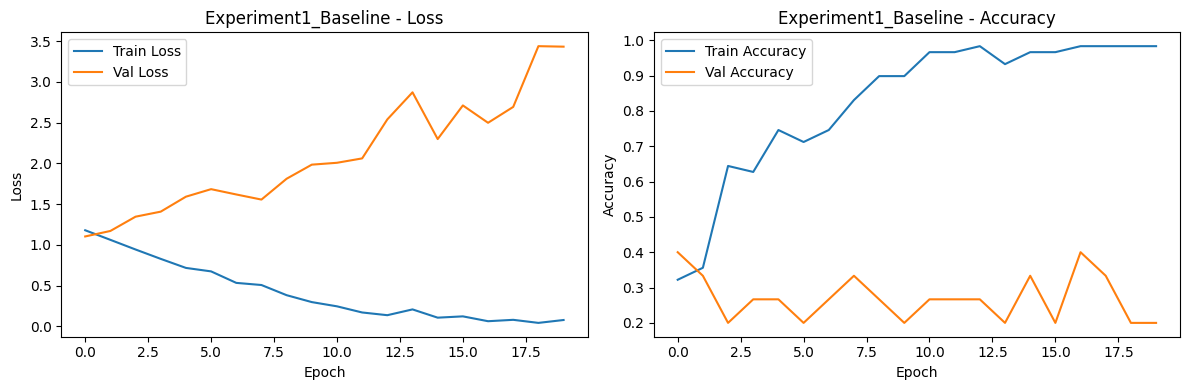

Plot saved as Experiment1_Baseline.png


In [17]:
# Experiment 1 - Baseline
# using default settings to see how the model performs normally

model = ShapeCNN()
train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, epochs=20, lr=0.001
)

plot_results(train_losses, val_losses, train_accs, val_accs, title="Experiment1_Baseline")

Epoch 1/20 | Train Loss: 1.1799 | Val Loss: 1.1625 | Train Acc: 0.3051 | Val Acc: 0.2000
Epoch 2/20 | Train Loss: 1.0583 | Val Loss: 1.1587 | Train Acc: 0.4746 | Val Acc: 0.2000
Epoch 3/20 | Train Loss: 1.0530 | Val Loss: 1.2092 | Train Acc: 0.4576 | Val Acc: 0.2667
Epoch 4/20 | Train Loss: 0.9594 | Val Loss: 1.3068 | Train Acc: 0.5593 | Val Acc: 0.2667
Epoch 5/20 | Train Loss: 0.9467 | Val Loss: 1.4295 | Train Acc: 0.5424 | Val Acc: 0.2000
Epoch 6/20 | Train Loss: 0.8093 | Val Loss: 1.4825 | Train Acc: 0.6441 | Val Acc: 0.1333
Epoch 7/20 | Train Loss: 0.7541 | Val Loss: 1.4515 | Train Acc: 0.7288 | Val Acc: 0.3333
Epoch 8/20 | Train Loss: 0.8326 | Val Loss: 1.4452 | Train Acc: 0.7288 | Val Acc: 0.1333
Epoch 9/20 | Train Loss: 0.7196 | Val Loss: 1.3392 | Train Acc: 0.7119 | Val Acc: 0.2667
Epoch 10/20 | Train Loss: 0.6348 | Val Loss: 1.4146 | Train Acc: 0.7797 | Val Acc: 0.2667
Epoch 11/20 | Train Loss: 0.5085 | Val Loss: 1.8408 | Train Acc: 0.8305 | Val Acc: 0.2000
Epoch 12/20 | Train

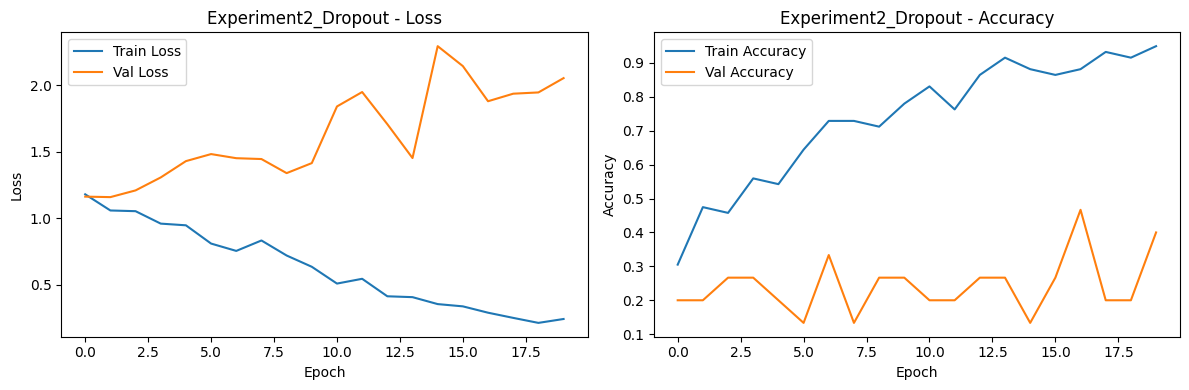

Plot saved as Experiment2_Dropout.png


In [18]:
# Experiment 2 - Adding Dropout
# i added dropout to reduce overfitting seen in baseline

class ShapeCNN_Dropout(nn.Module):
    def __init__(self):
        super(ShapeCNN_Dropout, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),  # randomly turns off 50% neurons
            nn.Linear(128, 3)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model2 = ShapeCNN_Dropout()
train_losses2, val_losses2, train_accs2, val_accs2 = train_model(
    model2, train_loader, val_loader, epochs=20, lr=0.001
)

plot_results(train_losses2, val_losses2, train_accs2, val_accs2, title="Experiment2_Dropout")

Epoch 1/20 | Train Loss: 1554.1760 | Val Loss: 152.2740 | Train Acc: 0.3559 | Val Acc: 0.3333
Epoch 2/20 | Train Loss: 52.8185 | Val Loss: 2.1271 | Train Acc: 0.2712 | Val Acc: 0.4000
Epoch 3/20 | Train Loss: 1.2609 | Val Loss: 7.9522 | Train Acc: 0.3220 | Val Acc: 0.1333
Epoch 4/20 | Train Loss: 2.4392 | Val Loss: 2.2721 | Train Acc: 0.2373 | Val Acc: 0.2000
Epoch 5/20 | Train Loss: 0.9646 | Val Loss: 3.2151 | Train Acc: 0.4407 | Val Acc: 0.2000
Epoch 6/20 | Train Loss: 0.8477 | Val Loss: 4.8863 | Train Acc: 0.5932 | Val Acc: 0.1333
Epoch 7/20 | Train Loss: 0.7989 | Val Loss: 3.7931 | Train Acc: 0.5254 | Val Acc: 0.1333
Epoch 8/20 | Train Loss: 0.7347 | Val Loss: 3.9919 | Train Acc: 0.6441 | Val Acc: 0.1333
Epoch 9/20 | Train Loss: 0.6326 | Val Loss: 3.6239 | Train Acc: 0.6271 | Val Acc: 0.2000
Epoch 10/20 | Train Loss: 0.6332 | Val Loss: 3.5749 | Train Acc: 0.6441 | Val Acc: 0.2667
Epoch 11/20 | Train Loss: 0.5915 | Val Loss: 4.1106 | Train Acc: 0.6441 | Val Acc: 0.2667
Epoch 12/20 |

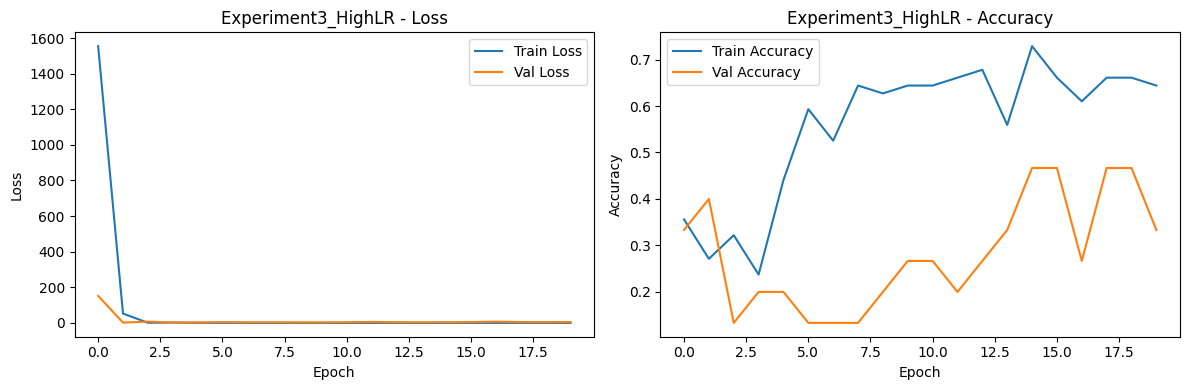

Plot saved as Experiment3_HighLR.png


In [19]:
# Experiment 3 - High Learning Rate
# i wanted to see what happens when learning rate is too high
# expected: unstable or diverging loss

model3 = ShapeCNN()
train_losses3, val_losses3, train_accs3, val_accs3 = train_model(
    model3, train_loader, val_loader, epochs=20, lr=0.1
)

plot_results(train_losses3, val_losses3, train_accs3, val_accs3, title="Experiment3_HighLR")

Epoch 1/20 | Train Loss: 1.1448 | Val Loss: 1.1959 | Train Acc: 0.3559 | Val Acc: 0.1333
Epoch 2/20 | Train Loss: 1.0270 | Val Loss: 1.5568 | Train Acc: 0.5254 | Val Acc: 0.2667
Epoch 3/20 | Train Loss: 0.9295 | Val Loss: 1.2358 | Train Acc: 0.5593 | Val Acc: 0.4000
Epoch 4/20 | Train Loss: 0.9120 | Val Loss: 1.4427 | Train Acc: 0.6271 | Val Acc: 0.2000
Epoch 5/20 | Train Loss: 0.6868 | Val Loss: 1.5450 | Train Acc: 0.7119 | Val Acc: 0.3333
Epoch 6/20 | Train Loss: 0.5365 | Val Loss: 1.6835 | Train Acc: 0.7288 | Val Acc: 0.4000
Epoch 7/20 | Train Loss: 0.3266 | Val Loss: 2.0738 | Train Acc: 0.8983 | Val Acc: 0.1333
Epoch 8/20 | Train Loss: 0.2095 | Val Loss: 3.5376 | Train Acc: 0.9153 | Val Acc: 0.4000
Epoch 9/20 | Train Loss: 0.3387 | Val Loss: 1.8539 | Train Acc: 0.8814 | Val Acc: 0.4000
Epoch 10/20 | Train Loss: 0.1546 | Val Loss: 2.4402 | Train Acc: 0.9831 | Val Acc: 0.4000
Epoch 11/20 | Train Loss: 0.0916 | Val Loss: 2.8330 | Train Acc: 0.9831 | Val Acc: 0.4667
Epoch 12/20 | Train

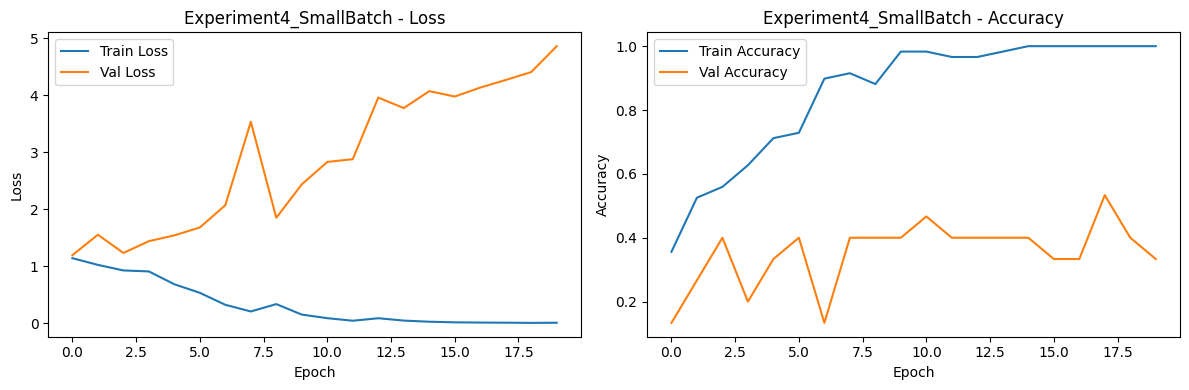

Plot saved as Experiment4_SmallBatch.png


In [20]:
# Experiment 4 - Small Batch Size
# smaller batch size means noisier updates
# i want to see how it affects training stability

train_loader_small = DataLoader(train_data, batch_size=4, shuffle=True)
val_loader_small = DataLoader(val_data, batch_size=4, shuffle=False)

model4 = ShapeCNN()
train_losses4, val_losses4, train_accs4, val_accs4 = train_model(
    model4, train_loader_small, val_loader_small, epochs=20, lr=0.001
)

plot_results(train_losses4, val_losses4, train_accs4, val_accs4, title="Experiment4_SmallBatch")

Epoch 1/20 | Train Loss: 2.5753 | Val Loss: 1.1512 | Train Acc: 0.3051 | Val Acc: 0.3333
Epoch 2/20 | Train Loss: 1.6343 | Val Loss: 1.3457 | Train Acc: 0.3898 | Val Acc: 0.2000
Epoch 3/20 | Train Loss: 1.1260 | Val Loss: 1.1912 | Train Acc: 0.5254 | Val Acc: 0.2667
Epoch 4/20 | Train Loss: 0.6809 | Val Loss: 1.2592 | Train Acc: 0.7119 | Val Acc: 0.2000
Epoch 5/20 | Train Loss: 0.6199 | Val Loss: 1.2847 | Train Acc: 0.7288 | Val Acc: 0.2000
Epoch 6/20 | Train Loss: 0.3308 | Val Loss: 1.1546 | Train Acc: 0.9492 | Val Acc: 0.4667
Epoch 7/20 | Train Loss: 0.2698 | Val Loss: 1.3854 | Train Acc: 0.9492 | Val Acc: 0.3333
Epoch 8/20 | Train Loss: 0.2175 | Val Loss: 1.6430 | Train Acc: 0.9322 | Val Acc: 0.2667
Epoch 9/20 | Train Loss: 0.1604 | Val Loss: 1.4764 | Train Acc: 0.9661 | Val Acc: 0.2667
Epoch 10/20 | Train Loss: 0.0977 | Val Loss: 1.2303 | Train Acc: 0.9661 | Val Acc: 0.4667
Epoch 11/20 | Train Loss: 0.0888 | Val Loss: 1.3220 | Train Acc: 0.9831 | Val Acc: 0.4667
Epoch 12/20 | Train

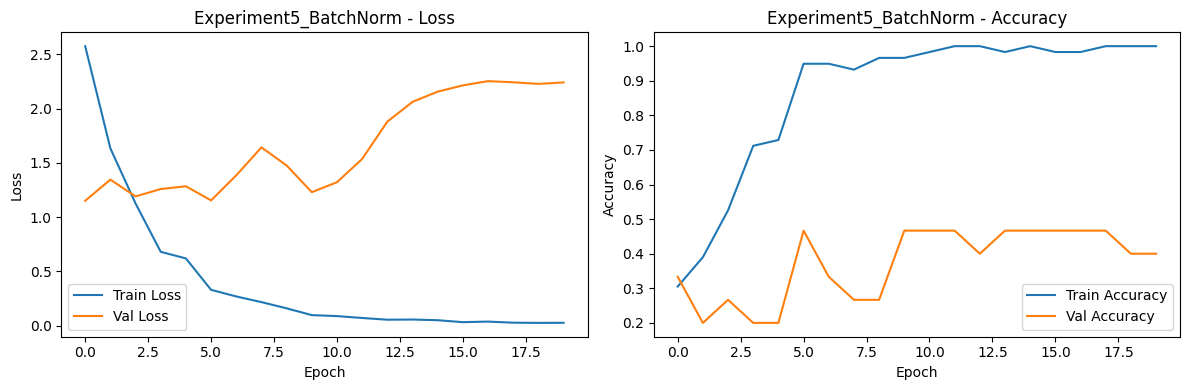

Plot saved as Experiment5_BatchNorm.png


In [21]:
# Experiment 5 - Batch Normalization
# batch norm normalizes inputs between layers
# should help training become more stable

class ShapeCNN_BatchNorm(nn.Module):
    def __init__(self):
        super(ShapeCNN_BatchNorm, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model5 = ShapeCNN_BatchNorm()
train_losses5, val_losses5, train_accs5, val_accs5 = train_model(
    model5, train_loader, val_loader, epochs=20, lr=0.001
)

plot_results(train_losses5, val_losses5, train_accs5, val_accs5, title="Experiment5_BatchNorm")